# Melhoria 1 — Balanceamento de Classes (class weight)

Este notebook aplica a primeira melhoria sobre a replicação do artigo de Ahmed et al. (2023).

## O problema
O dataset é desbalanceado: a classe Normal tem 8.153 imagens de treino, enquanto Tuberculosis tem apenas 555. Essa diferença (quase 15×) faz a rede aprender muito bem as classes grandes e mal as classes pequenas — foi justamente em Tuberculosis que tivemos o pior desempenho na replicação original (F1 de 95%).

## A solução: class weight
Em vez de alterar as imagens (duplicar ou descartar), atribuímos um **peso** a cada classe. Erros em classes raras passam a "custar" mais caro no cálculo da perda (loss), forçando a rede a prestar mais atenção nelas. É a técnica padrão para dados desbalanceados e não distorce os dados reais.

## Metodologia de comparação
Todos os demais parâmetros são **idênticos** ao notebook `02` (mesma arquitetura, mesma divisão com `seed=42`, mesmo otimizador). A única variável alterada é o balanceamento — assim, qualquer diferença no resultado é atribuível a ele.

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

# NOVO nesta melhoria: função que calcula os pesos de cada classe
from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow versão:", tf.__version__)

I0000 00:00:1791455856.701954     818 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1791455857.212298     818 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791455859.065209     818 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow versão: 2.21.0


## 2. Carregamento dos dados

Idêntico ao notebook `02`: carregamos as imagens da pasta `dataset_unificado` e dividimos em treino (80%) e teste (20%), usando os mesmos parâmetros e a mesma `seed` para garantir que a divisão seja exatamente a mesma da replicação original.

In [5]:
# Os caminhos das bases ficam no config.py (não versionado)
from config import RAIZ_COVID, RAIZ_PNEUMONIA, RAIZ_TUBERCULOSE

# Mesmos parâmetros do notebook 02 — nada muda aqui
TAMANHO_IMAGEM = (300, 300)
TAMANHO_LOTE = 32
SEED = 42

dataset_treino = keras.utils.image_dataset_from_directory(
    "dataset_unificado",
    image_size=TAMANHO_IMAGEM,
    batch_size=TAMANHO_LOTE,
    validation_split=0.2,
    subset="training",
    seed=SEED
)

dataset_teste = keras.utils.image_dataset_from_directory(
    "dataset_unificado",
    image_size=TAMANHO_IMAGEM,
    batch_size=TAMANHO_LOTE,
    validation_split=0.2,
    subset="validation",
    seed=SEED
)

# Guardamos os nomes das classes na ordem que o Keras usou
nomes_classes = dataset_treino.class_names
print("Classes:", nomes_classes)

Found 18781 files belonging to 4 classes.
Using 15025 files for training.
Found 18781 files belonging to 4 classes.
Using 3756 files for validation.
Classes: ['COVID-19', 'Normal', 'Pneumonia', 'Tuberculosis']


## 3. Coleta dos rótulos do treino

Para calcular os pesos, precisamos saber a qual classe pertence cada imagem de treino. Como o dataset do TensorFlow entrega as imagens em lotes sob demanda, percorremos ele uma vez para extrair todos os rótulos (0 = COVID-19, 1 = Normal, 2 = Pneumonia, 3 = Tuberculosis) e conferimos a contagem por classe.

In [3]:
# Passo 1: extrair o rótulo (0,1,2,3) de cada imagem do treino
# Percorremos o dataset de treino e vamos acumulando os rótulos
rotulos_treino = []
for imagens, rotulos in dataset_treino:
    rotulos_treino.extend(rotulos.numpy())

rotulos_treino = np.array(rotulos_treino)
print("Total de rótulos coletados:", len(rotulos_treino))

# Conferindo quantas imagens há de cada classe no treino
valores, contagens = np.unique(rotulos_treino, return_counts=True)
for v, c in zip(valores, contagens):
    print(f"  Classe {v} ({nomes_classes[v]}): {c} imagens")

Total de rótulos coletados: 15025
  Classe 0 (COVID-19): 2914 imagens
  Classe 1 (Normal): 8153 imagens
  Classe 2 (Pneumonia): 3403 imagens
  Classe 3 (Tuberculosis): 555 imagens


## 4. Cálculo dos pesos das classes

Usamos `compute_class_weight` com a estratégia `"balanced"`, que aplica a fórmula do inverso da frequência:

> peso da classe = total de imagens / (nº de classes × imagens daquela classe)

Quanto menos imagens uma classe tem, maior seu peso. O resultado é convertido para o formato de dicionário `{classe: peso}`, exigido pelo Keras. O efeito prático: cada classe passa a ter o mesmo "peso total" no treino, como se todas tivessem a mesma quantidade de imagens.

In [4]:
# Passo 2: calcular os pesos com a fórmula "balanced"
pesos_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(rotulos_treino),
    y=rotulos_treino
)

# O Keras quer no formato de dicionário: {indice_da_classe: peso}
pesos_classes = {i: peso for i, peso in enumerate(pesos_array)}

# Mostrando os pesos de forma legível
print("Pesos calculados por classe:\n")
for i, peso in pesos_classes.items():
    print(f"  Classe {i} ({nomes_classes[i]}): peso = {peso:.4f}")

Pesos calculados por classe:

  Classe 0 (COVID-19): peso = 1.2890
  Classe 1 (Normal): peso = 0.4607
  Classe 2 (Pneumonia): peso = 1.1038
  Classe 3 (Tuberculosis): peso = 6.7680


## 5. Construção do modelo

Arquitetura **idêntica** à da Tabela 3 do artigo, usada no notebook `02` (5 blocos convolucionais 16→32→64→128→256, dropout de 0.2, camada densa de 128 e saída softmax de 4 classes). Nada é alterado aqui — manter a arquitetura igual é o que permite isolar o efeito do balanceamento. Total: 3.047.460 parâmetros.

In [6]:
modelo = keras.Sequential([
    layers.Rescaling(1./255, input_shape=(300, 300, 3)),

    layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Dropout(0.2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(4, activation='softmax')
])

modelo.summary()

/home/gustavo/Documentos/GitHub/projetoInteligenciaArtificial/venv/lib/python3.13/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 300, 300, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 150, 150, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 150, 150, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,654,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,047,460 (11.63 MB)

 Trainable params: 3,047,460 (11.63 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Compilação e treino

A compilação é idêntica ao notebook `02`. A única diferença real do projeto inteiro está no `.fit()`: o parâmetro **`class_weight=pesos_classes`**, que injeta os pesos calculados no processo de treino.

O melhor modelo é salvo em `melhor_modelo_balanceado.keras` (nome diferente do notebook `02`, para não sobrescrever e permitir comparação).

**Observação:** com `class_weight`, o valor da perda (loss) exibido durante o treino aparece maior que no notebook `02`. Isso é esperado — os erros estão sendo multiplicados por pesos (alguns de até 6,77×), então a soma do erro naturalmente fica num patamar mais alto. O que importa para a comparação não é o valor absoluto do loss, e sim a acurácia de validação.

In [7]:
# Compilação — idêntica ao notebook 02
modelo.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Checkpoint — salva o melhor modelo, mas com NOME NOVO (não sobrescreve o do notebook 02)
checkpoint = keras.callbacks.ModelCheckpoint(
    "melhor_modelo_balanceado.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

# Treino — a ÚNICA diferença real: class_weight=pesos_classes
import time
inicio = time.time()

historico = modelo.fit(
    dataset_treino,
    validation_data=dataset_teste,
    epochs=30,
    callbacks=[checkpoint],
    class_weight=pesos_classes   # <<< a melhoria entra aqui
)

fim = time.time()
print(f"\nTempo total para 30 épocas: {(fim-inicio)/60:.1f} minutos")

Epoch 1/30


/home/gustavo/Documentos/GitHub/projetoInteligenciaArtificial/venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


470/470 ━━━━━━━━━━━━━━━━━━━━ 0s 940ms/step - accuracy: 0.7652 - loss: 0.5923
Epoch 1: val_accuracy improved from None to 0.83014, saving model to melhor_modelo_balanceado.keras

Epoch 1: finished saving model to melhor_modelo_balanceado.keras
470/470 ━━━━━━━━━━━━━━━━━━━━ 470s 997ms/step - accuracy: 0.7652 - loss: 0.5923 - val_accuracy: 0.8301 - val_loss: 0.3968
Epoch 2/30
470/470 ━━━━━━━━━━━━━━━━━━━━ 0s 937ms/step - accuracy: 0.9022 - loss: 0.2498
Epoch 2: val_accuracy improved from 0.83014 to 0.89963, saving model to melhor_modelo_balanceado.keras

Epoch 2: finished saving model to melhor_modelo_balanceado.keras
470/470 ━━━━━━━━━━━━━━━━━━━━ 468s 995ms/step - accuracy: 0.9022 - loss: 0.2498 - val_accuracy: 0.8996 - val_loss: 0.2543
Epoch 3/30
470/470 ━━━━━━━━━━━━━━━━━━━━ 0s 941ms/step - accuracy: 0.9308 - loss: 0.1732
Epoch 3: val_accuracy improved from 0.89963 to 0.93317, saving model to melhor_modelo_balanceado.keras

Epoch 3: finished saving model to melhor_modelo_balanceado.keras
4

## 7. Avaliação do modelo balanceado

Carregamos o melhor modelo salvo pelo checkpoint (`melhor_modelo_balanceado.keras`) e geramos as previsões sobre o conjunto de teste. A partir delas montamos a matriz de confusão e o relatório de métricas por classe, exatamente como na avaliação da replicação original — assim os resultados são diretamente comparáveis.

In [6]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Carrega o melhor modelo salvo pelo checkpoint
melhor_modelo = keras.models.load_model("melhor_modelo_balanceado.keras")

# Gera as previsões sobre o conjunto de teste
y_verdadeiro = []
y_previsto = []

for imagens, rotulos in dataset_teste:
    previsoes = melhor_modelo.predict(imagens, verbose=0)
    y_verdadeiro.extend(rotulos.numpy())
    y_previsto.extend(np.argmax(previsoes, axis=1))

y_verdadeiro = np.array(y_verdadeiro)
y_previsto = np.array(y_previsto)

print("Previsões geradas:", len(y_previsto))

Previsões geradas: 3756


In [7]:
print(classification_report(
    y_verdadeiro, y_previsto,
    target_names=nomes_classes,
    digits=4
))

              precision    recall  f1-score   support

    COVID-19     0.9537    0.9387    0.9462       702
      Normal     0.9824    0.9828    0.9826      2039
   Pneumonia     0.9954    0.9931    0.9942       870
Tuberculosis     0.9108    0.9862    0.9470       145

    accuracy                         0.9771      3756
   macro avg     0.9606    0.9752    0.9675      3756
weighted avg     0.9773    0.9771    0.9771      3756



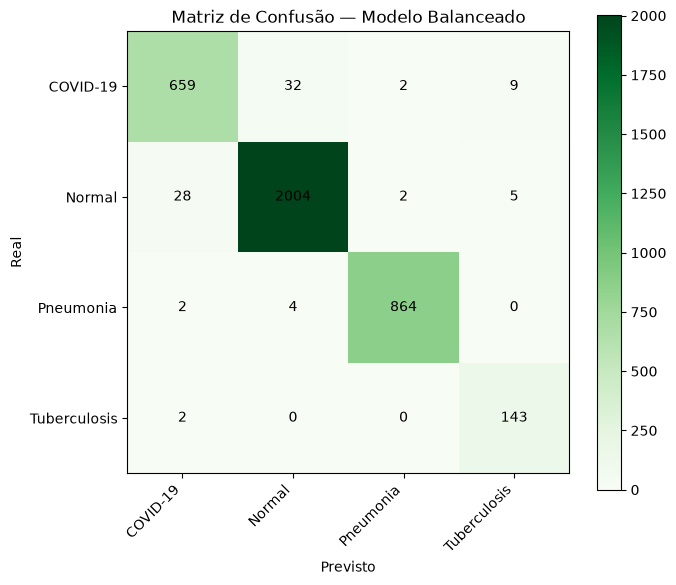

In [8]:
matriz = confusion_matrix(y_verdadeiro, y_previsto)

plt.figure(figsize=(7, 6))
plt.imshow(matriz, cmap="Greens")
plt.colorbar()
plt.xticks(range(4), nomes_classes, rotation=45, ha="right")
plt.yticks(range(4), nomes_classes)
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de Confusão — Modelo Balanceado")

# Escreve os números dentro de cada célula
for i in range(4):
    for j in range(4):
        plt.text(j, i, matriz[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

In [1]:
import random, pathlib
import numpy as np
import tensorflow as tf
from tensorflow import keras

# --- troque aqui para testar cada modelo ---
CAMINHO_MODELO = "melhor_modelo_balanceado.keras"
# CAMINHO_MODELO = "melhor_modelo_balanceado.keras"

modelo_teste = keras.models.load_model(CAMINHO_MODELO)

diretorio = pathlib.Path("dataset_unificado")
nomes_classes = sorted([p.name for p in diretorio.iterdir() if p.is_dir()])

N_POR_CLASSE = 25
random.seed(42)   # mesma seleção de imagens para todos os modelos

def preparar(caminho):
    img = tf.io.read_file(caminho)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (300, 300))
    return tf.expand_dims(img, 0)   # vira um "lote" de 1 imagem

# Matriz de contagem: linha = classe real, coluna = classe prevista
n = len(nomes_classes)
matriz = np.zeros((n, n), dtype=int)

for real, classe in enumerate(nomes_classes):
    arquivos = list((diretorio / classe).glob("*"))
    amostra = random.sample(arquivos, N_POR_CLASSE)
    for arq in amostra:
        previsto = int(np.argmax(modelo_teste.predict(preparar(str(arq)), verbose=0)))
        matriz[real][previsto] += 1

# ---- impressão formatada (estilo Tabela 5 do artigo) ----
largura = max(len(c) for c in nomes_classes) + 2
print("Real".ljust(largura) + "".join(c.ljust(largura) for c in nomes_classes) + "Acertos")
for real in range(n):
    linha = nomes_classes[real].ljust(largura)
    linha += "".join(str(matriz[real][j]).ljust(largura) for j in range(n))
    linha += f"{matriz[real][real]}/{N_POR_CLASSE}"
    print(linha)

I0000 00:00:1791548547.573633    3919 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1791548547.659735    3919 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791548549.731792    3919 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
E0000 00:00:1791548551.736144    3919 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Real          COVID-19      Normal        Pneumonia     Tuberculosis  Acertos
COVID-19      25            0             0             0             25/25
Normal        1             24            0             0             24/25
Pneumonia     0             0             25            0             25/25
Tuberculosis  0             0             0             25            25/25


In [ ]:
0,95